# Reencuadre y Reinterpretación

## Objetivo
Demostrar que cambiar el encuadre modifica el significado de la imagen.

## Requisitos
- Partir de una fotografía amplia
- Producir al menos dos reencuadres distintos
- La presentación debe incluir:
  - Fotografía original
  - Recorte A
  - Recorte B
  - Marcas indicando la región recortada

## 1. Importar librerías requeridas

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os
from pathlib import Path

# Configurar matplotlib para mejor visualización
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['figure.dpi'] = 100

In [12]:
from matplotlib.widgets import Slider

# FUNCIONES REUTILIZABLES
def create_crop_tool(img_array, imagen_original, nombre, color, x_left, y_top, x_right, y_bottom):
    """Crea una herramienta de recorte con sliders"""
    img_width, img_height = imagen_original.size
    
    fig = plt.figure(figsize=(15, 12))
    ax_img = plt.subplot(2, 1, 1)
    ax_img.imshow(img_array)
    ax_img.set_title(f'RECORTE {nombre}: Ajusta los bordes con los sliders', 
                     fontsize=14, fontweight='bold', color=color)
    
    rect_preview = patches.Rectangle((x_left, y_top), x_right - x_left, y_bottom - y_top,
                                     linewidth=3, edgecolor=color, facecolor='none')
    ax_img.add_patch(rect_preview)
    ax_img.axis('off')
    
    plt.subplots_adjust(bottom=0.35)
    
    slider_left = Slider(plt.axes([0.2, 0.25, 0.6, 0.03]), 'Izquierda', 0, img_width - 100, 
                         valinit=x_left, valstep=10, color=color)
    slider_top = Slider(plt.axes([0.2, 0.20, 0.6, 0.03]), 'Superior', 0, img_height - 100, 
                        valinit=y_top, valstep=10, color=color)
    slider_right = Slider(plt.axes([0.2, 0.15, 0.6, 0.03]), 'Derecha', 100, img_width, 
                          valinit=x_right, valstep=10, color=color)
    slider_bottom = Slider(plt.axes([0.2, 0.10, 0.6, 0.03]), 'Inferior', 100, img_height, 
                           valinit=y_bottom, valstep=10, color=color)
    
    def update(val):
        rect_preview.set_xy((int(slider_left.val), int(slider_top.val)))
        rect_preview.set_width(int(slider_right.val) - int(slider_left.val))
        rect_preview.set_height(int(slider_bottom.val) - int(slider_top.val))
        fig.canvas.draw_idle()
    
    for slider in [slider_left, slider_top, slider_right, slider_bottom]:
        slider.on_changed(update)
    
    plt.show()
    coords = (int(slider_left.val), int(slider_top.val), int(slider_right.val), int(slider_bottom.val))
    print(f"✓ Recorte {nombre} finalizado: {coords}")
    return coords

def show_crop(crop_coords, imagen_original, nombre, color):
    """Muestra un recorte"""
    if crop_coords is None:
        print(f"⚠ Recorte {nombre} no definido")
        return None
    crop = imagen_original.crop(crop_coords)
    plt.figure(figsize=(8, 6))
    plt.imshow(np.array(crop))
    plt.title(f'Recorte {nombre}', fontsize=14, fontweight='bold', color=color)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    print(f"Dimensiones: {crop.size[0]} x {crop.size[1]} px")
    return crop

## 2. Cargar la imagen original

INFORMACIÓN DEL DIRECTORIO
Directorio actual: c:\Users\cmpat\OneDrive\Escritorio\Repositorio\Patricio-Velasquez-Christian-PDI-1c-2026\006_fotografia_digital\codigo
Carpeta de imágenes: c:\Users\cmpat\OneDrive\Escritorio\Repositorio\Patricio-Velasquez-Christian-PDI-1c-2026\006_fotografia_digital\imagenes\originales

IMÁGENES DISPONIBLES
  1. imagencamaraoscura.jpg (541.7 KB)
  2. imagenreencuadre1.jpg (2478.9 KB)
  3. imagensimplicidadvisual.jpg (5321.6 KB)
Imagen seleccionada: imagenreencuadre1.jpg

✓ Imagen cargada correctamente
Nombre: imagenreencuadre1.jpg
Ruta absoluta: c:\Users\cmpat\OneDrive\Escritorio\Repositorio\Patricio-Velasquez-Christian-PDI-1c-2026\006_fotografia_digital\imagenes\originales\imagenreencuadre1.jpg
Tamaño del archivo: 2478.9 KB
Dimensiones: (5633, 2443) (ancho x alto)


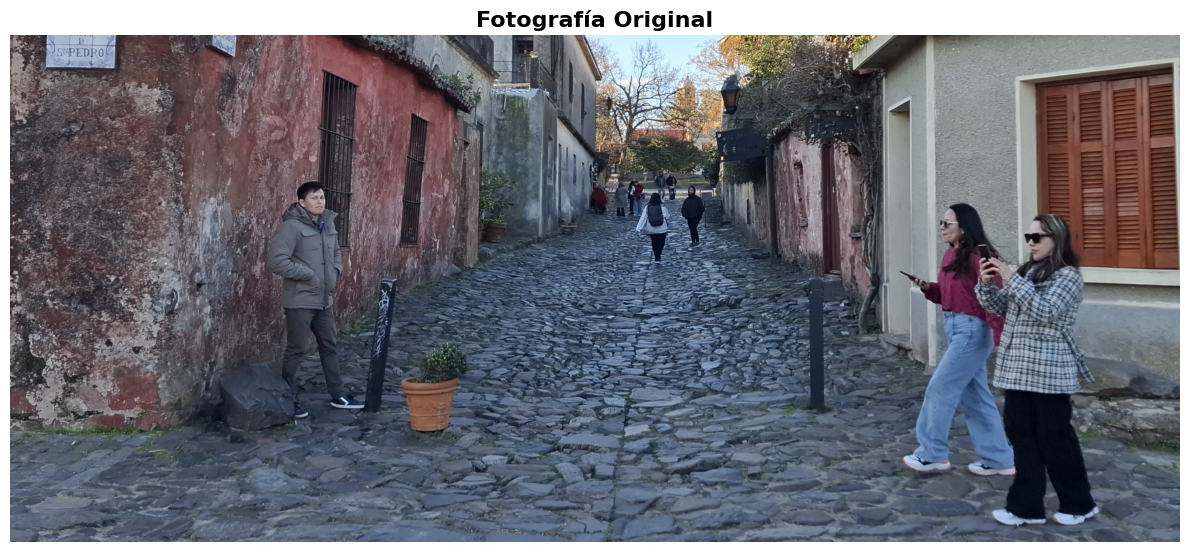

In [13]:
# Configurar la ruta de la carpeta de imágenes usando os
# Desde 'codigo' subir un nivel (..) e ir a 'imagenes/originales'
carpeta_imagenes = os.path.join('..', 'imagenes', 'originales')
carpeta_absoluta = os.path.abspath(carpeta_imagenes)

print("=" * 60)
print("INFORMACIÓN DEL DIRECTORIO")
print("=" * 60)
print(f"Directorio actual: {os.getcwd()}")
print(f"Carpeta de imágenes: {carpeta_absoluta}")
print()

# Validar que la carpeta existe
if not os.path.exists(carpeta_imagenes):
    print(f"✗ ERROR: Carpeta no encontrada: {carpeta_absoluta}")
    raise FileNotFoundError(f"La carpeta {carpeta_imagenes} no existe")

# Listar imágenes disponibles usando os
print("=" * 60)
print("IMÁGENES DISPONIBLES")
print("=" * 60)

archivos = []
for archivo in os.listdir(carpeta_imagenes):
    ruta_completa = os.path.join(carpeta_imagenes, archivo)
    # Verificar que es archivo y tiene extensión de imagen
    if os.path.isfile(ruta_completa) and archivo.lower().endswith(('.jpg', '.jpeg', '.png', '.gif', '.bmp')):
        archivos.append(archivo)

if archivos:
    for i, archivo in enumerate(archivos, 1):
        tamaño = os.path.getsize(os.path.join(carpeta_imagenes, archivo))
        print(f"  {i}. {archivo} ({tamaño / 1024:.1f} KB)")
else:
    print("  ✗ No hay imágenes disponibles en la carpeta")
    raise FileNotFoundError("No se encontraron imágenes en la carpeta")

# Nombre de la imagen a cargar
print("=" * 60)
nombre_imagen = 'imagenreencuadre1.jpg'
print(f"Imagen seleccionada: {nombre_imagen}")

# Construir la ruta completa usando os
ruta_imagen = os.path.join(carpeta_imagenes, nombre_imagen)
ruta_absoluta = os.path.abspath(ruta_imagen)

# Validar usando os
if not os.path.exists(ruta_imagen):
    print(f"\n✗ No se encontró: {nombre_imagen}")
    print(f"Ruta buscada: {ruta_absoluta}")
    raise FileNotFoundError(f"El archivo {nombre_imagen} no existe en {carpeta_absoluta}")

if not os.path.isfile(ruta_imagen):
    print(f"\n✗ No es un archivo válido: {nombre_imagen}")
    raise TypeError(f"{ruta_imagen} no es un archivo")

# Cargar la imagen
imagen_original = Image.open(ruta_imagen).convert('RGB')
print(f"\n✓ Imagen cargada correctamente")
print(f"Nombre: {nombre_imagen}")
print(f"Ruta absoluta: {ruta_absoluta}")
print(f"Tamaño del archivo: {os.path.getsize(ruta_imagen) / 1024:.1f} KB")
print(f"Dimensiones: {imagen_original.size} (ancho x alto)")

# Convertir a numpy array para visualización
img_array = np.array(imagen_original)

# Mostrar la imagen original
plt.figure(figsize=(12, 8))
plt.imshow(img_array)
plt.title('Fotografía Original', fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## 3. Recorte A

Usa los sliders para ajustar el primer recorte

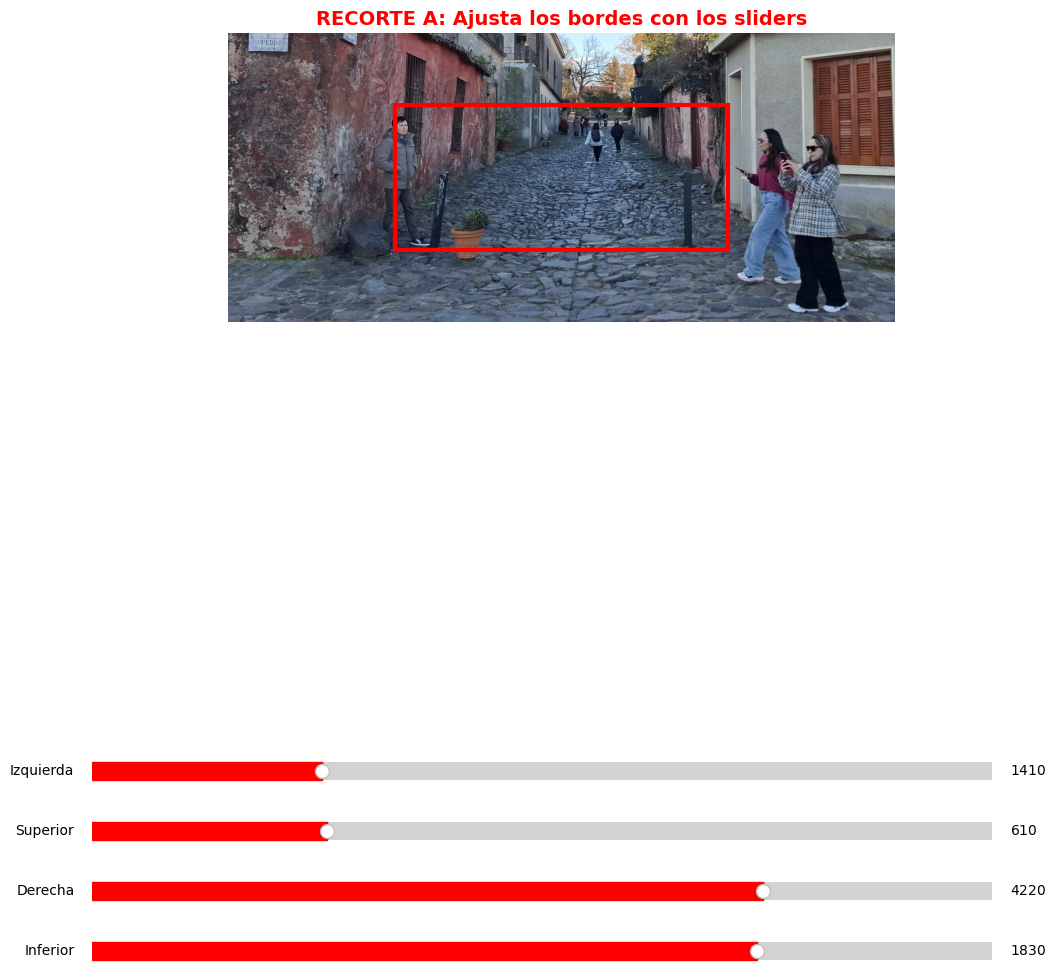

✓ Recorte A finalizado: (1410, 610, 4220, 1830)


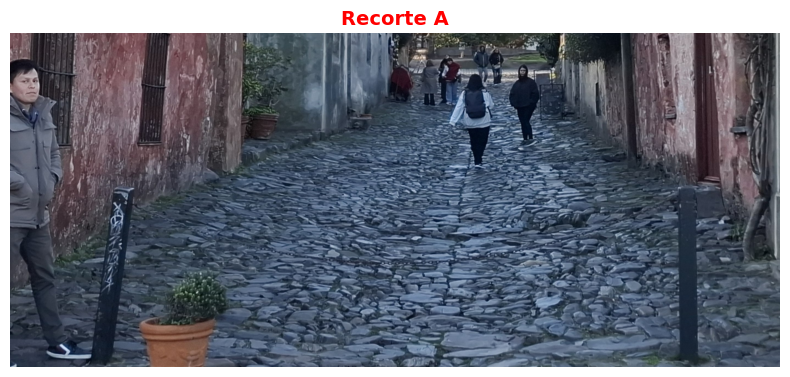

Dimensiones: 2810 x 1220 px


In [14]:
# RECORTE A
x_left_A, y_top_A = imagen_original.size[0] // 4, imagen_original.size[1] // 4
x_right_A, y_bottom_A = 3 * imagen_original.size[0] // 4, 3 * imagen_original.size[1] // 4

crop_A_coords = create_crop_tool(img_array, imagen_original, 'A', 'red', 
                                 x_left_A, y_top_A, x_right_A, y_bottom_A)
crop_A = show_crop(crop_A_coords, imagen_original, 'A', 'red')

### 3.1 Ajuste manual (Opcional)

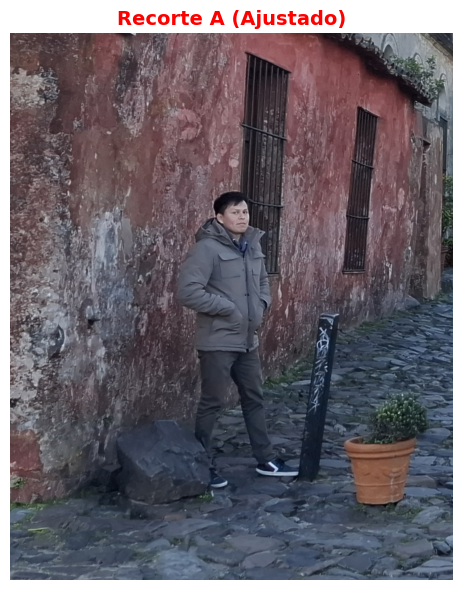

Dimensiones: 1700 x 2100 px


In [15]:
# AJUSTE MANUAL RECORTE A (OPCIONAL)
crop_A_coords = (600, 100, 2300, 2200)  # DESCOMENTA Y EDITA SI NECESITAS VALORES EXACTOS
crop_A = show_crop(crop_A_coords, imagen_original, 'A (Ajustado)', 'red')

## 4. Recorte B

Usa los sliders para ajustar el segundo recorte

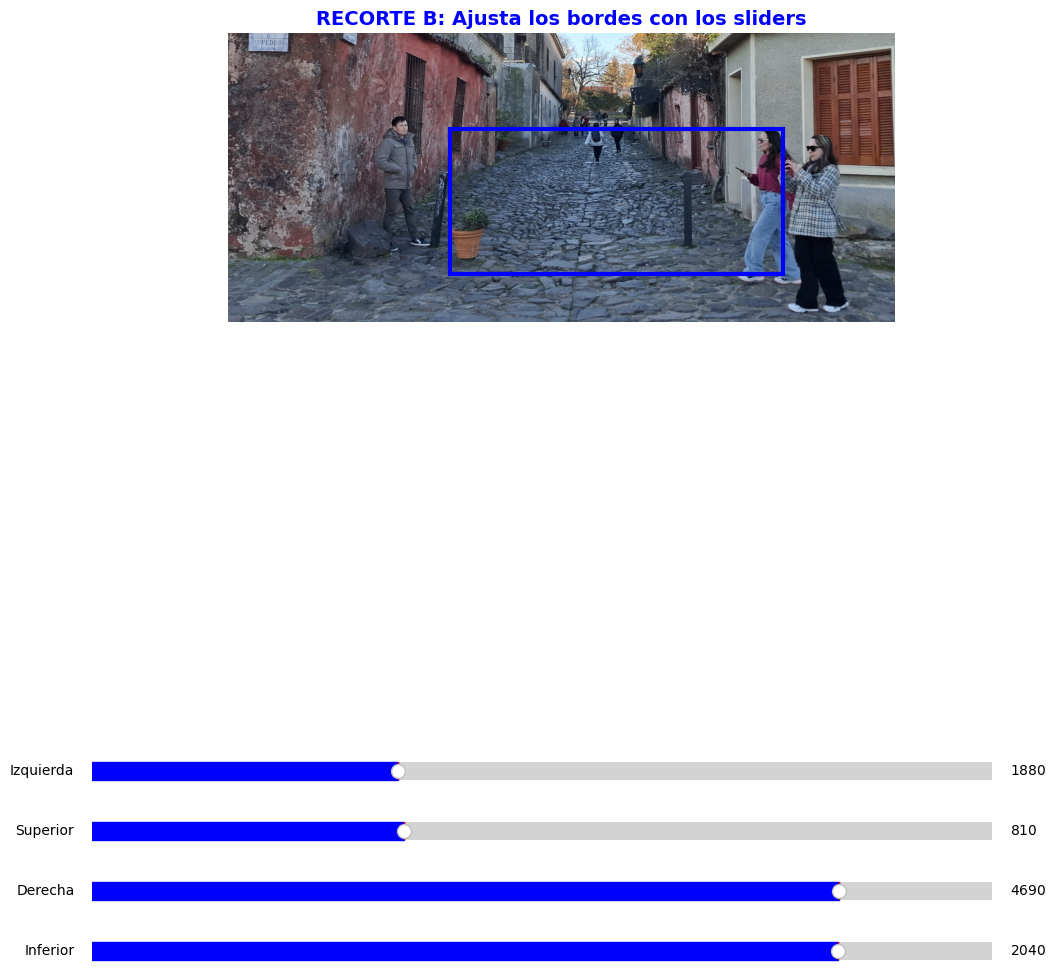

✓ Recorte B finalizado: (1880, 810, 4690, 2040)


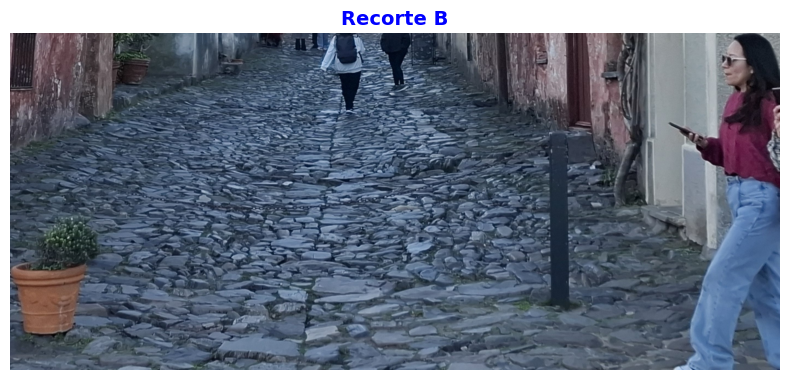

Dimensiones: 2810 x 1230 px


In [16]:
# RECORTE B
x_left_B, y_top_B = imagen_original.size[0] // 3, imagen_original.size[1] // 3
x_right_B = 2 * imagen_original.size[0] // 3 + imagen_original.size[0] // 6
y_bottom_B = 2 * imagen_original.size[1] // 3 + imagen_original.size[1] // 6

crop_B_coords = create_crop_tool(img_array, imagen_original, 'B', 'blue', 
                                 x_left_B, y_top_B, x_right_B, y_bottom_B)
crop_B = show_crop(crop_B_coords, imagen_original, 'B', 'blue')

### 4.1 Ajuste manual (Opcional)

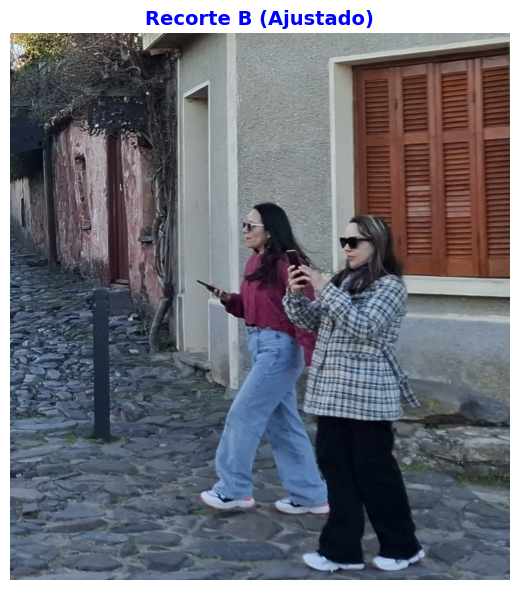

Dimensiones: 2100 x 2300 px


In [17]:
# AJUSTE MANUAL RECORTE B (OPCIONAL)
crop_B_coords = (3500, 100, 5600, 2400)  # DESCOMENTA Y EDITA SI NECESITAS VALORES EXACTOS
crop_B = show_crop(crop_B_coords, imagen_original, 'B (Ajustado)', 'blue')

## 6. Visualizar regiones marcadas

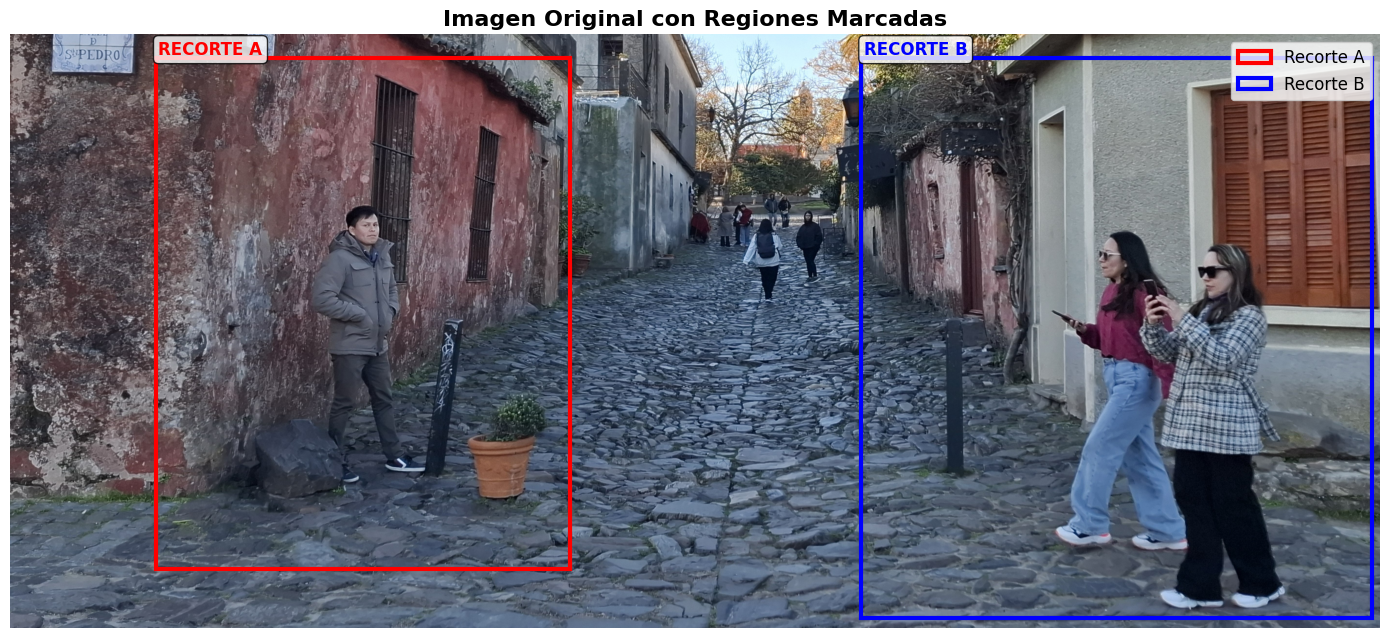

In [21]:
# VISUALIZAR REGIONES MARCADAS
fig, ax = plt.subplots(1, 1, figsize=(14, 10))
ax.imshow(img_array)

crops = [('A', crop_A_coords, 'red'), ('B', crop_B_coords, 'blue')]


for nombre, coords, color in crops:
    if coords:
        rect = patches.Rectangle((coords[0], coords[1]), coords[2] - coords[0], 
                                coords[3] - coords[1], linewidth=3, edgecolor=color, 
                                facecolor='none', label=f'Recorte {nombre}')
        ax.add_patch(rect)
        ax.text(coords[0] + 10, coords[1] - 15, f'RECORTE {nombre}', color=color, 
               fontsize=12, fontweight='bold', bbox=dict(boxstyle='round', 
               facecolor='white', alpha=0.8))

ax.set_title('Imagen Original con Regiones Marcadas', fontsize=16, fontweight='bold')
ax.legend(loc='upper right', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()

## 7. Guardar resultados

In [28]:
# Guardar recortes en la carpeta de procesadas
from datetime import datetime

# Desde 'codigo' subir un nivel (..) e ir a 'imagenes/procesadas'
carpeta_procesadas = os.path.join('..', 'imagenes', 'procesadas')
os.makedirs(carpeta_procesadas, exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Guardar recorte A
if crop_A:
    archivo_A = os.path.join(carpeta_procesadas, f'recorte_A_{timestamp}.png')
    if not os.path.exists(archivo_A):
        crop_A.save(archivo_A)
        print(f"✓ Recorte A guardado: {archivo_A}")
    else:
        print(f"⚠ Recorte A ya existe: {archivo_A}")

# Guardar recorte B
if crop_B:
    archivo_B = os.path.join(carpeta_procesadas, f'recorte_B_{timestamp}.png')
    if not os.path.exists(archivo_B):
        crop_B.save(archivo_B)
        print(f"✓ Recorte B guardado: {archivo_B}")
    else:
        print(f"⚠ Recorte B ya existe: {archivo_B}")

print(f"\n✅ Directorio de guardado: {os.path.abspath(carpeta_procesadas)}")

✓ Recorte A guardado: ..\imagenes\procesadas\recorte_A_20260513_042105.png
✓ Recorte B guardado: ..\imagenes\procesadas\recorte_B_20260513_042105.png

✅ Directorio de guardado: c:\Users\cmpat\OneDrive\Escritorio\Repositorio\Patricio-Velasquez-Christian-PDI-1c-2026\006_fotografia_digital\imagenes\procesadas


## Reflexión: ¿Qué ocurre después del crop?

**¿Qué se vuelve importante?**
El contexto eliminado. Lo que queda en el encuadre adquiere mayor peso visual; el fondo, las relaciones espaciales y el punto de interés se redistribuyen.

**¿Qué información desaparece?**
El entorno, las referencias de escala, elementos secundarios, y parte de la intención original del autor. Se pierde contexto narrativo o espacial.

**¿El sujeto cambia?**
No físicamente, pero sí su rol: puede pasar de ser un elemento entre varios a ser el protagonista absoluto, o perder sentido si se aisla de su contexto.

**¿La imagen se vuelve más narrativa o más abstracta?**
Depende del crop. Un recorte cerrado sobre texturas o formas tiende a lo **abstracto**; un recorte que aísla un momento o personaje puede volverse más **narrativo**. El reencuadre resignifica la imagen.